# Flood Risk Prediction

# FLOOD RISK PREDICTION

## 1.Problem Definition
Flooding is one of the most devastating natural disasters, often resulting in loss of life, displacement, and destruction of property and infrastructure. Accurate and timely flood risk prediction is critical for disaster preparedness, urban planning, and climate resilience efforts. 

### Statistics
On average, floods affect at least 45,000 people annually, with some years seeing hundreds of thousands displaced. 

Deaths:
Floods have caused at least 480 deaths in recent years. In 2021, they accounted for 39% of disaster-related deaths. 

In May 2024, floods affected 39,185 people in 14 districts within 11 days.  
In November 2019, floods and landslides in Bundibugyo, Bududa, and Sironko districts resulted in at least 38 deaths and over 150 injuries, affecting an estimated 300,000 people, according to ReliefWeb.  
In April 2023, floods and landslides in Kasese, Mbale, and Rukungiri districts resulted in multiple deaths and displacement.  
In November 2023, the Uganda Red Cross Society reported 25,000 people already affected by floods and anticipated further impacts due to the El Niño period, according to Anticipation Hub. 

### Mbarara in Specific
 A notable instance occurred in March 2018 when a heavy downpour caused the Rwizi River to overflow, resulting in at least one death and damage to buildings, including a hotel under construction. 
 More recently, in May 2023, heavy rains disrupted business activities and submerged the NWSC system after the Rwizi River breached its banks, according to The Cooperator News.


## Solution
A machine learning-powered flood risk prediction system that estimates the probability of flooding in a given region based on 20+ environmental, climatic, and infrastructural indicators. By transforming complex data into real-time flood probability scores and risk categories, the model empowers governments, city planners, and disaster management teams to make data-driven decisions that minimize flood impact, enhance early warning systems, and protect vulnerable communities."


**What we shall do:**
- Problem Definition & Motivation
- Data Cleaning & Preprocessing
- Feature Engineering & Selection
- Exploratory Data Analysis (EDA) with visualizations
- Model Selection & Baseline Comparisons
- Model Training, Evaluation, and Interpretation

In [1]:
# ## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib as jl


/home/tj/miniconda3/envs/mlWork/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## 3. Data Acquisition, Cleaning and Preprocessing

We managed to acquire a dataset from kaggle.com with sufficient information to train our model. It seemed well processed already but we decided to have our own take on it, for the sake of research and understanding the underlying principles of handling datasets for ML.

In [6]:
# ## 2. Load and Preprocess Data
# Load the dataset and handle missing or infinite values.

df = pd.read_csv('synthetic_flood_dataset_uganda_seasonal.csv')

# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Visualize target variable distribution
# plt.figure(figsize=(8, 6))
# sns.kdeplot(df['FloodProbability'], shade=True, color='blue')
# plt.title('Target Variable Distribution')
# plt.legend(['Flood Probability'])
# plt.show()

df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning',
       'PoliticalFactors', 'WetlandLoss', 'FloodProbability'],
      dtype='object')

## Feature Engineering 

In [ ]:
# ## 3. Feature Engineering
# Add engineered features for flood probability and flood size.

# # Existing feature engineering
# df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']
# df['Urbanization_Encroachment'] = df['Urbanization'] * df['Encroachments']
# df['ClimateVulnerability'] = df[['ClimateChange', 'CoastalVulnerability', 'WetlandLoss']].mean(axis=1)
# df['InfrastructureQuality'] = df[['RiverManagement', 'DamsQuality', 'DrainageSystems']].mean(axis=1)

# New engineered features for flood size
# Normalize features to [0, 1] for consistent scales
scaler = MinMaxScaler()
features_to_normalize = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices',
    'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems',
    'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure',
    'PopulationScore', 'InadequatePlanning', 'PoliticalFactors', 'WetlandLoss'
]
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

# Flood size features
df['RunoffPotential'] = (
    df['MonsoonIntensity'] + df['Urbanization'] + df['Deforestation'] +
    df['AgriculturalPractices'] + df['Siltation']
) / 5

df['DrainageCapacity'] = (
    df['TopographyDrainage'] + df['RiverManagement'] +
    df['DrainageSystems'] + df['DamsQuality']
) / 4

df['FloodSpreadPotential'] = (
    df['WetlandLoss'] + df['Encroachments'] +
    df['CoastalVulnerability'] + (1 - df['Watersheds'])
) / 4

df['VulnerabilityIndex'] = (
    df['PopulationScore'] + df['InadequatePlanning'] +
    df['IneffectiveDisasterPreparedness'] + df['PoliticalFactors']
) / 4

df['FloodSizeScore'] = (
    df['RunoffPotential'] + df['FloodSpreadPotential'] - df['DrainageCapacity']
)

df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,PopulationScore,InadequatePlanning,PoliticalFactors,WetlandLoss,FloodProbability,RunoffPotential,DrainageCapacity,FloodSpreadPotential,VulnerabilityIndex,FloodSizeScore
0,0.699638,0.115357,0.543904,0.548606,0.724898,0.815114,0.925689,0.282724,0.204573,0.682875,...,0.598331,0.382407,0.516567,0.710155,0.318474,0.492088,0.475039,0.527694,0.544413,0.544742
1,0.858283,0.498308,0.500538,0.134755,0.663978,0.478018,0.947342,0.098674,0.337034,0.055911,...,0.820672,0.332341,0.777266,0.460041,0.325668,0.418545,0.606317,0.251344,0.669949,0.063572
2,0.156304,0.605686,0.369901,0.506914,0.575049,0.550587,0.784991,0.379124,0.363857,0.217157,...,0.521355,0.606323,0.386754,0.489898,0.393855,0.396250,0.572454,0.253516,0.557773,0.077311
3,0.477457,0.275397,0.563282,0.035249,0.312544,0.336499,0.677326,0.684285,0.109222,0.553529,...,0.070463,0.672838,0.299675,0.377143,0.346498,0.323751,0.501972,0.440574,0.285678,0.262353
4,0.901851,0.397805,0.228118,0.361197,0.740139,0.483558,0.770245,0.032464,0.756281,0.592566,...,0.221980,0.341805,0.483305,0.681281,0.443101,0.558386,0.479013,0.404643,0.344821,0.484016


In [8]:
# ## 4. Prepare Data for Modeling
# Define features and targets. We'll predict both FloodProbability and FloodSizeScore.

X = df.drop(['FloodProbability', 'FloodSizeScore', 'VulnerabilityIndex'], axis=1)  # Features (including engineered ones)
y = df[['FloodProbability', 'FloodSizeScore', 'VulnerabilityIndex']]  # Targets (multi-output)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'InadequatePlanning',
       'PoliticalFactors', 'WetlandLoss', 'RunoffPotential',
       'DrainageCapacity', 'FloodSpreadPotential'],
      dtype='object')

In [9]:
# ## 5. Model Comparison
# Compare multiple regression algorithms for multi-output prediction.

# Define models
models = {
    'Linear Regression': MultiOutputRegressor(LinearRegression()),
    'Ridge Regression': MultiOutputRegressor(Ridge(alpha=1.0)),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, random_state=42)),
    'XGBoost': MultiOutputRegressor(XGBRegressor(n_estimators=100, random_state=42))
}

# Store results
results = {
    'Model': [],
    'FloodProbability_MSE': [],
    'FloodProbability_R2': [],
    'FloodProbability_MAE': [],
    'FloodSizeScore_MSE': [],
    'FloodSizeScore_R2': [],
    'FloodSizeScore_MAE': [],
    'VulnerabilityIndex_MSE': [],
    'VulnerabilityIndex_R2': [],
    'VulnerabilityIndex_MAE': [],
    'CV_R2_Probability': [],
    'CV_R2_Size': [],
    'CV_R2_Vulnerability': [] 
}

# Train and evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_prob, y_pred_size, y_pred_vul = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
    y_test_prob, y_test_size, y_pred_vul = y_test['FloodProbability'], y_test['FloodSizeScore'], y_test['VulnerabilityIndex']
    
    # Metrics
    results['Model'].append(name)
    results['FloodProbability_MSE'].append(mean_squared_error(y_test_prob, y_pred_prob))
    results['FloodProbability_R2'].append(r2_score(y_test_prob, y_pred_prob))
    results['FloodProbability_MAE'].append(mean_absolute_error(y_test_prob, y_pred_prob))
    results['FloodSizeScore_MSE'].append(mean_squared_error(y_test_size, y_pred_size))
    results['FloodSizeScore_R2'].append(r2_score(y_test_size, y_pred_size))
    results['FloodSizeScore_MAE'].append(mean_absolute_error(y_test_size, y_pred_size))
    results['VulnerabilityIndex_MSE'].append(mean_squared_error(y_test['VulnerabilityIndex'], y_pred_vul))
    results['VulnerabilityIndex_R2'].append(r2_score(y_test['VulnerabilityIndex'], y_pred_vul))
    results['VulnerabilityIndex_MAE'].append(mean_absolute_error(y_test['VulnerabilityIndex'], y_pred_vul))

    # Cross-validation for multi-output
    cv_results = cross_validate(model, X, y, cv=5, scoring='r2', return_train_score=False)
    results['CV_R2_Probability'].append(cv_results['test_score'].mean())  # Average R² for FloodProbability
    results['CV_R2_Size'].append(cv_results['test_score'].mean())  # Average R² for FloodSizeScore 
    results['CV_R2_Vulnerability'].append(cv_results['test_score'].mean())  # Average R² for VulnerabilityIndex

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
print("Model Comparison Results:")
print(results_df)

Model Comparison Results:
               Model  FloodProbability_MSE  FloodProbability_R2  \
0  Linear Regression              0.002554             0.627992   
1   Ridge Regression              0.002554             0.627991   
2      Random Forest              0.003702             0.460829   
3  Gradient Boosting              0.002648             0.614354   
4            XGBoost              0.003007             0.562036   

   FloodProbability_MAE  FloodSizeScore_MSE  FloodSizeScore_R2  \
0              0.040070        1.239769e-31           1.000000   
1              0.040073        1.566561e-07           0.999996   
2              0.048249        1.181957e-03           0.972451   
3              0.040951        2.402069e-04           0.994401   
4              0.043615        3.891382e-04           0.990930   

   FloodSizeScore_MAE  VulnerabilityIndex_MSE  VulnerabilityIndex_R2  \
0        2.792072e-16                     0.0                    1.0   
1        3.170184e-04         

In [ ]:
# ## 6. Visualize Model Performance
# Plot metrics to compare models.

plt.figure(figsize=(18, 8))

# R² for FloodProbability
plt.subplot(2, 3, 1)
sns.barplot(x='FloodProbability_R2', y='Model', data=results_df)
plt.title('R² Score for Flood Probability')
plt.xlabel('R²')

# R² for FloodSizeScore
plt.subplot(2, 3, 2)
sns.barplot(x='FloodSizeScore_R2', y='Model', data=results_df)
plt.title('R² Score for Flood Size Score')
plt.xlabel('R²')

# R² for VulnerabilityIndex
plt.subplot(2, 3, 3)
sns.barplot(x='VulnerabilityIndex_R2', y='Model', data=results_df)
plt.title('R² Score for Vulnerability Index')
plt.xlabel('R²')

# MAE for FloodProbability
plt.subplot(2, 3, 4)
sns.barplot(x='FloodProbability_MAE', y='Model', data=results_df)
plt.title('MAE for Flood Probability')
plt.xlabel('MAE')

# MAE for FloodSizeScore
plt.subplot(2, 3, 5)
sns.barplot(x='FloodSizeScore_MAE', y='Model', data=results_df)
plt.title('MAE for Flood Size Score')
plt.xlabel('MAE')

# MAE for VulnerabilityIndex
plt.subplot(2, 3, 6)
sns.barplot(x='VulnerabilityIndex_MAE', y='Model', data=results_df)
plt.title('MAE for Vulnerability Index')
plt.xlabel('MAE')

plt.tight_layout()
plt.show()


Best Model: Linear Regression

Best Model (Linear Regression) Test Set Performance:
Flood Probability Metrics:
Mean Squared Error: 0.0026
R² Score: 0.6280
Mean Absolute Error: 0.0401

Flood Size Score Metrics:
Mean Squared Error: 0.0000
R² Score: 1.0000
Mean Absolute Error: 0.0000


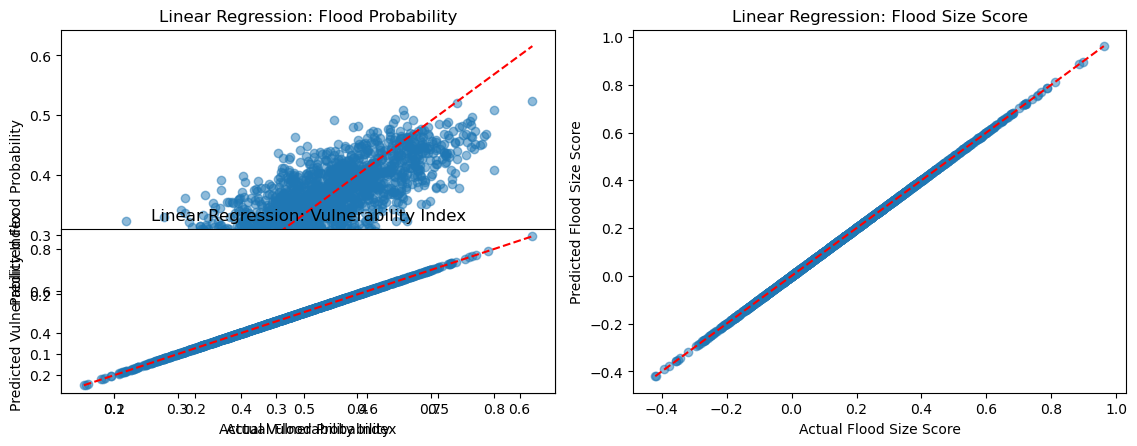

In [10]:
# ## 7. Select and Train Best Model
# Select the model with the highest average R² across both targets.

results_df['Avg_R2'] = (results_df['FloodProbability_R2'] + results_df['FloodSizeScore_R2']) / 2
best_model_name = results_df.loc[results_df['Avg_R2'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

# Retrain best model on full training data
best_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_pred_prob, y_pred_size, y_pred_vul = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
y_test_prob, y_test_size, y_pred_vul = y_test['FloodProbability'], y_test['FloodSizeScore'], y_test['VulnerabilityIndex']

print(f"\nBest Model ({best_model_name}) Test Set Performance:")
print("Flood Probability Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_prob, y_pred_prob):.4f}")
print(f"R² Score: {r2_score(y_test_prob, y_pred_prob):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_prob, y_pred_prob):.4f}")
print("\nFlood Size Score Metrics:")

print(f"Mean Squared Error: {mean_squared_error(y_test_size, y_pred_size):.4f}")
print(f"R² Score: {r2_score(y_test_size, y_pred_size):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_size, y_pred_size):.4f}")

# Visualize predictions vs actuals
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_prob, y_pred_prob, alpha=0.5)
diag_line = np.linspace(y_test_prob.min(), y_test_prob.max(), 100)
plt.plot(diag_line, diag_line, 'r--')
plt.xlabel('Actual Flood Probability')
plt.ylabel('Predicted Flood Probability')
plt.title(f'{best_model_name}: Flood Probability')

plt.subplot(1, 2, 2)
plt.scatter(y_test_size, y_pred_size, alpha=0.5)
plt.plot([y_test_size.min(), y_test_size.max()], [y_test_size.min(), y_test_size.max()], 'r--')
plt.xlabel('Actual Flood Size Score')
plt.ylabel('Predicted Flood Size Score')
plt.title(f'{best_model_name}: Flood Size Score')

plt.subplot(2, 2, 3)
plt.scatter(y_test['VulnerabilityIndex'], y_pred_vul, alpha=0.5)
plt.plot([y_test['VulnerabilityIndex'].min(), y_test['VulnerabilityIndex'].max()], 
         [y_test['VulnerabilityIndex'].min(), y_test['VulnerabilityIndex'].max()], 'r--')
plt.xlabel('Actual Vulnerability Index')
plt.ylabel('Predicted Vulnerability Index')
plt.title(f'{best_model_name}: Vulnerability Index')


plt.tight_layout()
plt.show()

# Feature importance (if applicable)
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance_Probability': best_model.feature_importances_[0] if best_model_name == 'Random Forest' else best_model.estimators_[0].feature_importances_,
        'Importance_Size': best_model.feature_importances_[1] if best_model_name == 'Random Forest' else best_model.estimators_[1].feature_importances_,
        'Importance_Vulnerability': best_model.feature_importances_[2] if best_model_name == 'Random Forest' else best_model.estimators_[2].feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance_Probability', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance_Probability', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance for Flood Probability ({best_model_name})')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance_Size', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance for Flood Size Score ({best_model_name})')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance_Vulnerability', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance for Vulnerability Index ({best_model_name})')
    plt.show()

In [11]:
# ## 8. Save the Best Model
# Save the trained model and scaler for future use.

jl.dump(best_model, 'flood_prediction_model.pkl')
jl.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:


# ## 9. Example Prediction
# Predict for a sample input from the external scoring system, including all features.

# Create a sample input with features that match those scaled during training
sample_input = pd.DataFrame({
    'MonsoonIntensity': [0.7],  # Adjusted for July (high monsoon season)
    'TopographyDrainage': [0.5],
    'RiverManagement': [0.6],
    'Deforestation': [0.4],
    'Urbanization': [0.8],
    'ClimateChange': [0.5],
    'DamsQuality': [0.6],
    'Siltation': [0.4],
    'AgriculturalPractices': [0.5],
    'Encroachments': [0.7],
    'IneffectiveDisasterPreparedness': [0.6],
    'DrainageSystems': [0.5],
    'CoastalVulnerability': [0.3],
    'Landslides': [0.4],
    'Watersheds': [0.6],
    'DeterioratingInfrastructure': [0.5],
    'PopulationScore': [0.8],
    'WetlandLoss': [0.7],
    'InadequatePlanning': [0.6],
    'PoliticalFactors': [0.5]
})

# Load scaler and apply to sample input
scaler = jl.load('scaler.pkl')
sample_input_scaled = scaler.transform(sample_input)

# Compute flood size features using scaled values
sample_input_scaled_df = pd.DataFrame(sample_input_scaled, columns=sample_input.columns)
sample_input_scaled_df['RunoffPotential'] = (
    sample_input_scaled_df['MonsoonIntensity'] + sample_input_scaled_df['Urbanization'] +
    sample_input_scaled_df['Deforestation'] + sample_input_scaled_df['AgriculturalPractices'] +
    sample_input_scaled_df['Siltation']
) / 5

sample_input_scaled_df['DrainageCapacity'] = (
    sample_input_scaled_df['TopographyDrainage'] + sample_input_scaled_df['RiverManagement'] +
    sample_input_scaled_df['DrainageSystems'] + sample_input_scaled_df['DamsQuality']
) / 4

sample_input_scaled_df['FloodSpreadPotential'] = (
    sample_input_scaled_df['WetlandLoss'] + sample_input_scaled_df['Encroachments'] +
    sample_input_scaled_df['CoastalVulnerability'] + (1 - sample_input_scaled_df['Watersheds'])
) / 4

sample_input_scaled_df['VulnerabilityIndex'] = (
    sample_input_scaled_df['PopulationScore'] + sample_input_scaled_df['InadequatePlanning'] +
    sample_input_scaled_df['IneffectiveDisasterPreparedness'] + sample_input_scaled_df['PoliticalFactors']
) / 4

sample_input_scaled_df['FloodSizeScore'] = (
    sample_input_scaled_df['RunoffPotential'] + sample_input_scaled_df['FloodSpreadPotential'] -
    sample_input_scaled_df['DrainageCapacity']
)

# Ensure feature order matches X
sample_input_final = sample_input_scaled_df[X.columns]
# print(sample_input_final.head())
# Predict using the best model
prediction = best_model.predict(sample_input_final)
print(f"Sample Prediction ({best_model_name}) - Flood Probability: {prediction[0, 0]:.4f}, Flood Size Score: {prediction[0, 1]:.4f}, Vulnerability Index: {prediction[0, 2]:.4f}")